In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv('netflix_movies_detailed_up_to_2025.csv')

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

Dataset Shape: (16000, 18)

Columns:

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average', 'budget',
       'revenue'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  la

In [ ]:
print("Missing Values:\n")

df.isnull().sum()

Missing Values:



,0
show_id,0
type,0
title,0
director,132
cast,204
country,466
date_added,0
release_year,0
rating,0
duration,16000


In [ ]:
# Summary statistics for numerical columns

df.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


In [ ]:
df.describe(include='object')

,type,title,director,cast,country,date_added,genres,language,description
count,16000,16000,15868,15796,15534,16000,15893,16000,15868
unique,1,15485,9508,15639,1463,4423,2768,74,15854
top,Movie,Eden,Tyler Perry,"Wasabi Mizuta, Megumi Oohara, Yumi Kakazu, Sub...",United States of America,2025-03-07,Drama,en,A narrative short film.
freq,16000,6,20,10,5421,103,1336,9534,9


In [ ]:
# Select numerical columns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
show_id,1.000000,0.928273,-0.325255,NaN,0.096656,-0.185147,-0.325255,-0.141630,-0.114259
release_year,0.928273,1.000000,-0.230341,NaN,0.131493,-0.106090,-0.230341,-0.036975,-0.043304
rating,-0.325255,-0.230341,1.000000,NaN,0.071178,0.173600,1.000000,0.096967,0.117231
duration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,0.096656,0.131493,0.071178,NaN,1.000000,0.158254,0.071178,0.218221,0.216282
vote_count,-0.185147,-0.106090,0.173600,NaN,0.158254,1.000000,0.173600,0.666053,0.749207
vote_average,-0.325255,-0.230341,1.000000,NaN,0.071178,0.173600,1.000000,0.096967,0.117231
budget,-0.141630,-0.036975,0.096967,NaN,0.218221,0.666053,0.096967,1.000000,0.752193
revenue,-0.114259,-0.043304,0.117231,NaN,0.216282,0.749207,0.117231,0.752193,1.000000


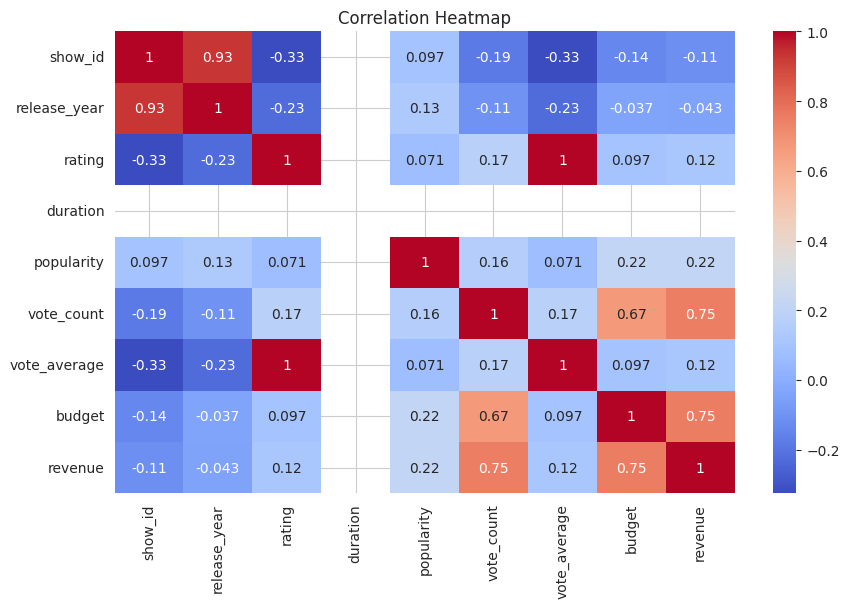

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

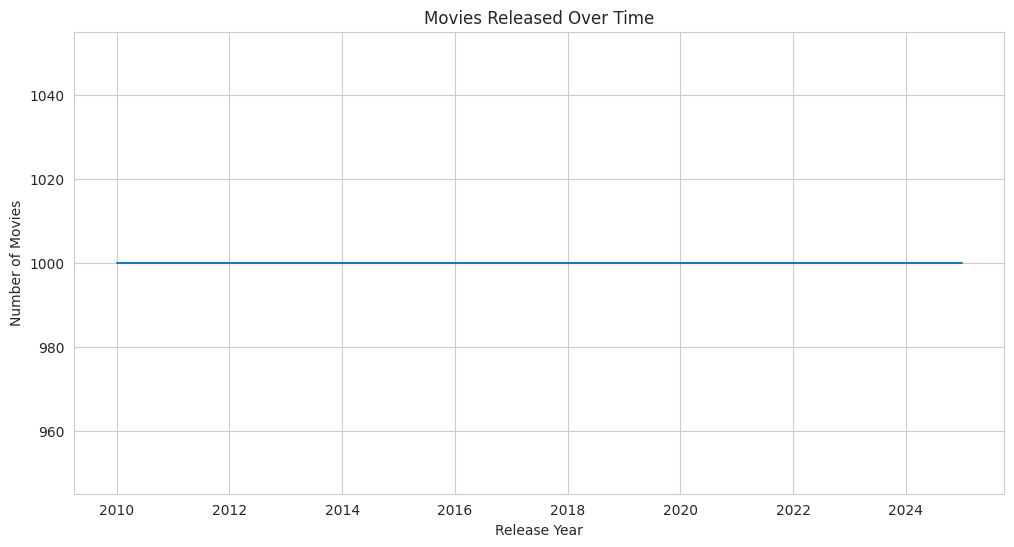

In [ ]:
plt.figure(figsize=(12,6))

df['release_year'].value_counts().sort_index().plot()

plt.title("Movies Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

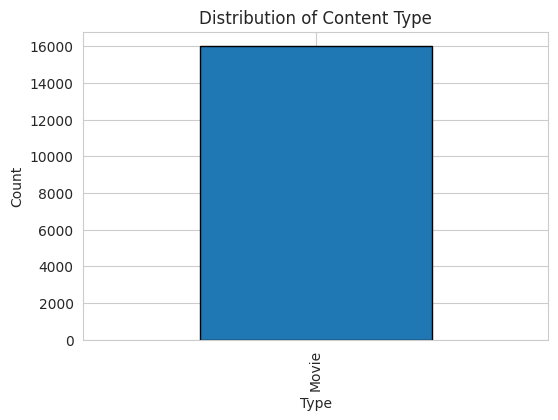

In [ ]:
plt.figure(figsize=(6,4))

df['type'].value_counts().plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

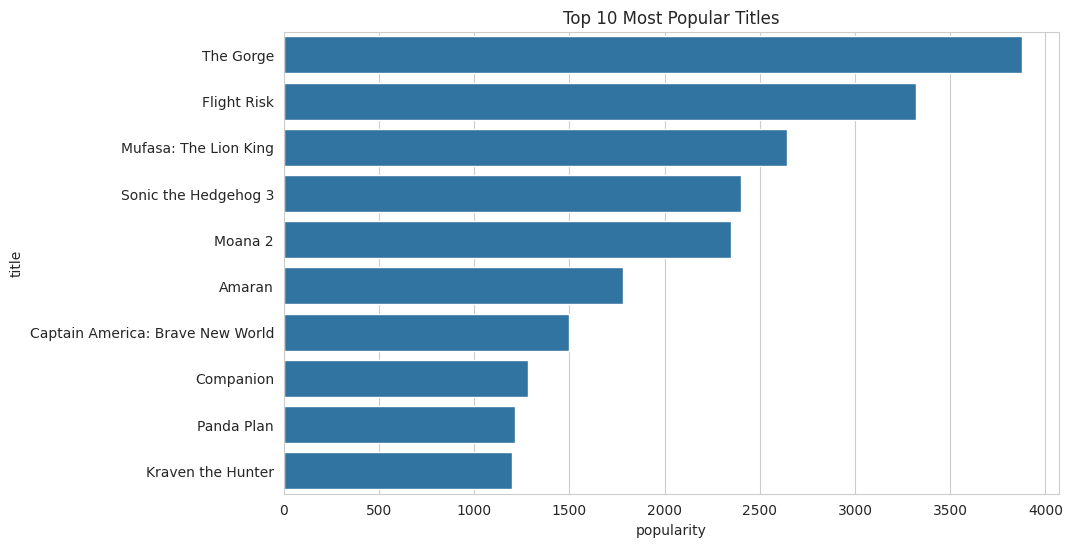

In [ ]:
top_popular = df.nlargest(10, 'popularity')

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_popular,
    x='popularity',
    y='title'
)

plt.title("Top 10 Most Popular Titles")

plt.show()

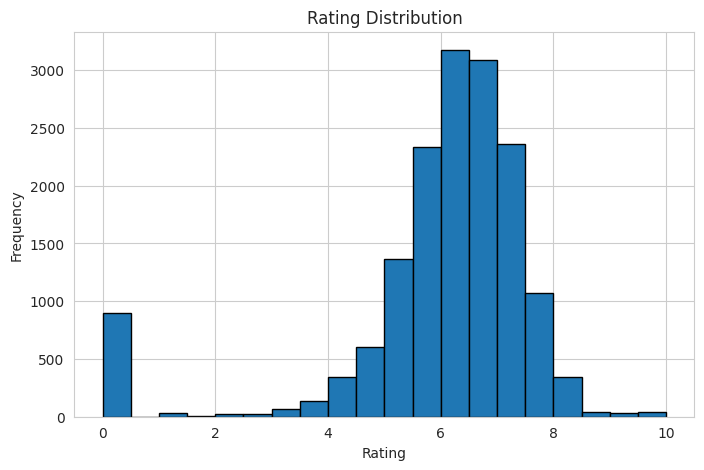

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df['rating'],
    bins=20,
    edgecolor='black'
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

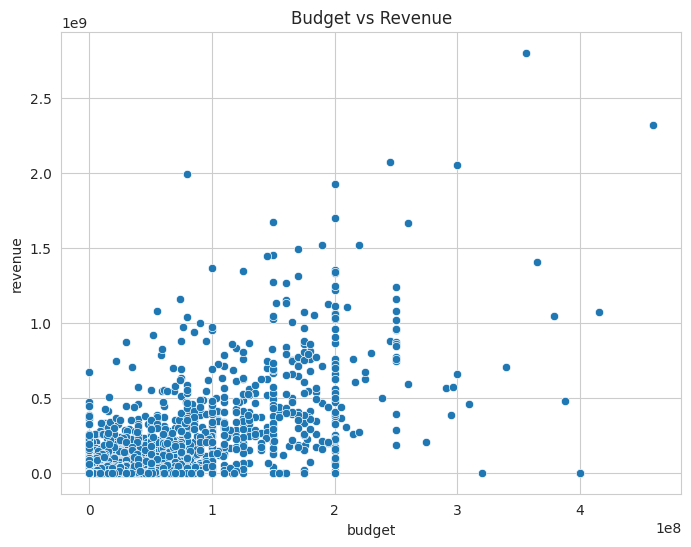

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='budget',
    y='revenue'
)

plt.title("Budget vs Revenue")

plt.show()

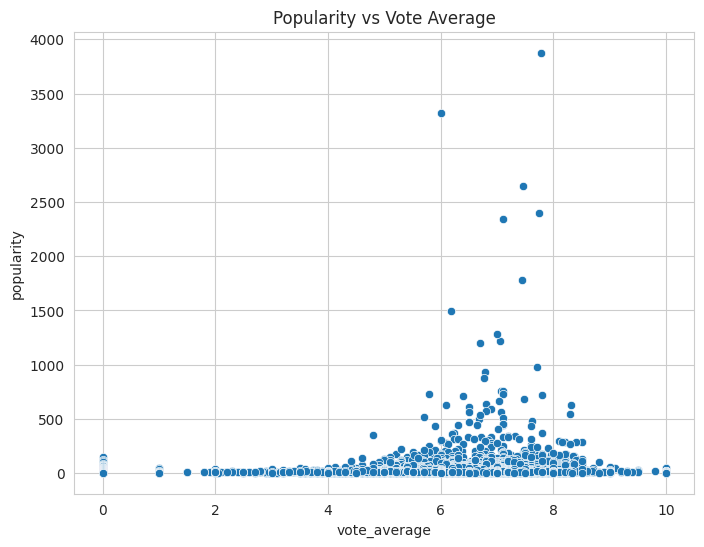

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='vote_average',
    y='popularity'
)

plt.title("Popularity vs Vote Average")

plt.show()

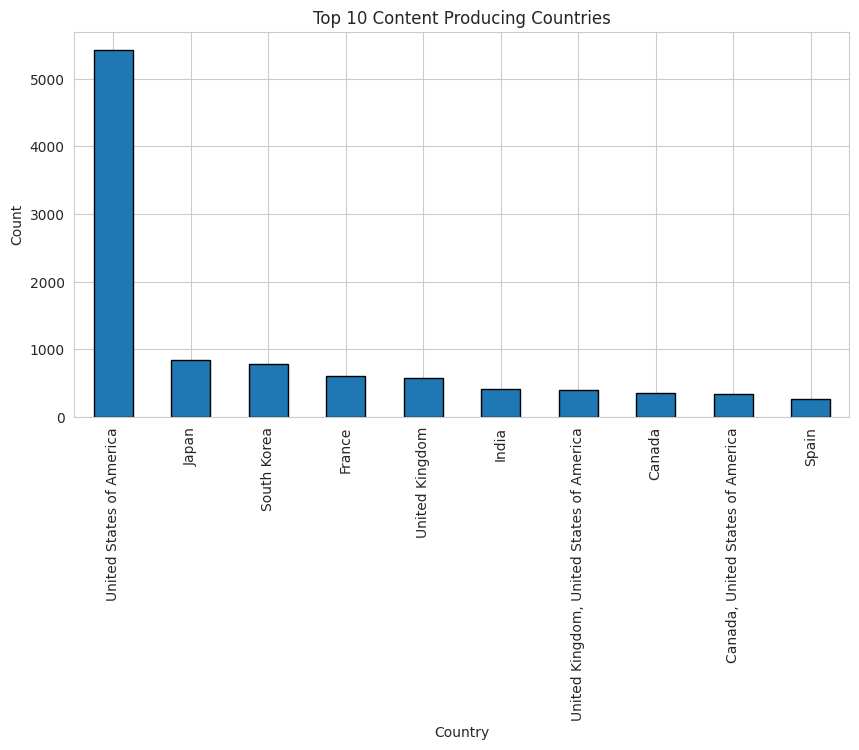

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

In [ ]:
print("""
EDA Insights:

1. Release trends reveal growth in content production over time.

2. Correlation heatmap identifies relationships among
   popularity, votes, budget, and revenue.

3. Higher-budget productions generally generate
   higher revenues.

4. Ratings are concentrated around average-to-good scores.

5. Certain countries dominate Netflix content production.

6. Popularity tends to increase with audience engagement
   (vote counts and ratings).
""")


EDA Insights:

1. Release trends reveal growth in content production over time.

2. Correlation heatmap identifies relationships among
   popularity, votes, budget, and revenue.

3. Higher-budget productions generally generate
   higher revenues.

4. Ratings are concentrated around average-to-good scores.

5. Certain countries dominate Netflix content production.

6. Popularity tends to increase with audience engagement
   (vote counts and ratings).

